## Tugas Scrapping dan EDA

## 1. Scrapping Dataset

In [29]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import matplotlib.pyplot as plt


In [2]:
url = "https://news.ycombinator.com/newest"

response = requests.get(url)

print(response.status_code)

200


In [3]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title)

<title>New Links | Hacker News</title>


In [4]:
posts = soup.find_all("tr", class_="athing")

print(len(posts))

30


In [7]:
first_post = posts[0]

titleline = first_post.find("span", class_="titleline")

title = titleline.find("a").get_text(strip=True)

sitebit = titleline.find("span", class_="sitebit")
domain = (
    sitebit.get_text(strip=True).strip("()")
    if sitebit else None
)

print("Title :", title)
print("Domain:", domain)

Title : For most of history, people's conversations, thoughts, and finances were private
Domain: grapheneos.social


In [9]:
subtext = first_post.find_next_sibling("tr")

score_tag = subtext.find("span", class_="score")
points = int(score_tag.get_text(strip=True).split()[0]) if score_tag else 0

author_tag = subtext.find("a", class_="hnuser")
author = author_tag.get_text(strip=True) if author_tag else None

age_tag = subtext.find("span", class_="age")
age = age_tag.get_text(strip=True) if age_tag else None

links = subtext.find_all("a")
comment_text = links[-1].get_text(strip=True) if links else "discuss"

if "comment" in comment_text:
    comments = int(comment_text.split()[0])
else:
    comments = 0

print("Points  :", points)
print("Author  :", author)
print("Age     :", age)
print("Comments:", comments)

Points  : 1
Author  : Cider9986
Age     : 1 minute ago
Comments: 0


In [10]:
data = []

for post in posts:
    titleline = post.find("span", class_="titleline")
    title = titleline.find("a").get_text(strip=True)

    sitebit = titleline.find("span", class_="sitebit")
    domain = (
        sitebit.get_text(strip=True).strip("()")
        if sitebit else None
    )

    subtext = post.find_next_sibling("tr")

    score_tag = subtext.find("span", class_="score")
    points = int(score_tag.get_text(strip=True).split()[0]) if score_tag else 0

    author_tag = subtext.find("a", class_="hnuser")
    author = author_tag.get_text(strip=True) if author_tag else None

    age_tag = subtext.find("span", class_="age")
    age = age_tag.get_text(strip=True) if age_tag else None

    links = subtext.find_all("a")
    comment_text = links[-1].get_text(strip=True) if links else "discuss"

    if "comment" in comment_text:
        comments = int(comment_text.split()[0])
    else:
        comments = 0

    data.append({
        "title": title,
        "domain": domain,
        "points": points,
        "author": author,
        "age": age,
        "comments": comments
    })

In [11]:
print(len(data))

30


In [12]:
df = pd.DataFrame(data)

df.head()

,title,domain,points,author,age,comments
0,"For most of history, people's conversations, t...",grapheneos.social,1,Cider9986,1 minute ago,0
1,Cursor Projects,cursor.com,1,deadalus,1 minute ago,0
2,Show HN: Automatically keep track of all featu...,github.com/netizer,1,krzysiek,2 minutes ago,0
3,Roads – the UKs favourite roads website,roads.org.uk,1,ColinEberhardt,8 minutes ago,0
4,Only 31% of startup accelerators publish what ...,accelerator.directory,2,buidlr,9 minutes ago,0


In [13]:
data_all = []

url = "https://news.ycombinator.com/newest"

while len(data_all) < 1500:
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    posts = soup.find_all("tr", class_="athing")

    for post in posts:
        titleline = post.find("span", class_="titleline")

        title = titleline.find("a").get_text(strip=True)

        sitebit = titleline.find("span", class_="sitebit")
        domain = (
            sitebit.get_text(strip=True).strip("()")
            if sitebit else None
        )

        subtext = post.find_next_sibling("tr")

        score_tag = subtext.find("span", class_="score")
        points = (
            int(score_tag.get_text(strip=True).split()[0])
            if score_tag else 0
        )

        author_tag = subtext.find("a", class_="hnuser")
        author = (
            author_tag.get_text(strip=True)
            if author_tag else None
        )

        age_tag = subtext.find("span", class_="age")
        age = (
            age_tag.get_text(strip=True)
            if age_tag else None
        )

        links = subtext.find_all("a")
        comment_text = (
            links[-1].get_text(strip=True)
            if links else "discuss"
        )

        if "comment" in comment_text:
            comments = int(comment_text.split()[0])
        else:
            comments = 0

        data_all.append({
            "title": title,
            "domain": domain,
            "points": points,
            "author": author,
            "age": age,
            "comments": comments
        })

        if len(data_all) >= 1500:
            break

    more_link = soup.find("a", class_="morelink")

    if more_link:
        url = "https://news.ycombinator.com/" + more_link["href"]
    else:
        break

    time.sleep(1)

In [14]:
df = pd.DataFrame(data_all)

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])

df.head()

Jumlah baris : 1500
Jumlah kolom : 6


,title,domain,points,author,age,comments
0,Show HN: Oxlint plugin to auto-fix non-canonic...,github.com/maharshi365,1,maharship2022,1 minute ago,0
1,Anthropic is lying: Moonshot is not routing to...,twitter.com/trydotworks,1,try-working,3 minutes ago,0
2,Proposal: Cmd/cgo: cgo without a C toolchain,github.com/golang,1,mappu,4 minutes ago,0
3,Predicting AI Job Exposure,ben-evans.com,1,saikatsg,5 minutes ago,0
4,Read Independent Fiction,eveningnotes.bearblog.dev,1,saikatsg,7 minutes ago,0


In [15]:
print("Jumlah baris          :", len(df))
print("Jumlah baris duplikat :", df.duplicated().sum())
print("Jumlah title unik     :", df["title"].nunique())

Jumlah baris          : 1500
Jumlah baris duplikat : 0
Jumlah title unik     : 1480


In [16]:
df.to_csv("hackernews_raw.csv", index=False)

print("Dataset berhasil disimpan.")

Dataset berhasil disimpan.


## 2. Import dan Pemahaman Dataset

In [17]:
df = pd.read_csv("hackernews_raw.csv")

df.head()

,title,domain,points,author,age,comments
0,Show HN: Oxlint plugin to auto-fix non-canonic...,github.com/maharshi365,1,maharship2022,1 minute ago,0
1,Anthropic is lying: Moonshot is not routing to...,twitter.com/trydotworks,1,try-working,3 minutes ago,0
2,Proposal: Cmd/cgo: cgo without a C toolchain,github.com/golang,1,mappu,4 minutes ago,0
3,Predicting AI Job Exposure,ben-evans.com,1,saikatsg,5 minutes ago,0
4,Read Independent Fiction,eveningnotes.bearblog.dev,1,saikatsg,7 minutes ago,0


In [18]:
print("Shape dataset:", df.shape)

print("\nTipe data setiap kolom:")
print(df.dtypes)

print("\nInformasi dataset:")
df.info()

Shape dataset: (1500, 6)

Tipe data setiap kolom:
title         str
domain        str
points      int64
author        str
age           str
comments    int64
dtype: object

Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   title     1500 non-null   str  
 1   domain    1446 non-null   str  
 2   points    1500 non-null   int64
 3   author    1500 non-null   str  
 4   age       1500 non-null   str  
 5   comments  1500 non-null   int64
dtypes: int64(2), str(4)
memory usage: 70.4 KB


### Identifikasi Tipe Atribut

| Atribut | Tipe Atribut | Penjelasan |
|---|---|---|
| title | Nominal | Judul postingan yang berfungsi sebagai identitas atau kategori teks tanpa urutan. |
| domain | Nominal | Sumber atau domain postingan yang tidak memiliki tingkatan atau urutan. |
| points | Numerik diskrit | Jumlah poin berupa hasil hitungan dalam bilangan bulat. |
| author | Nominal | Nama pengguna pembuat postingan yang tidak memiliki urutan. |
| age | Numerik kontinu* | Menunjukkan waktu sejak postingan dibuat dan dapat diubah menjadi satuan waktu numerik. |
| comments | Numerik diskrit | Jumlah komentar berupa hasil hitungan dalam bilangan bulat. |

## 3. Analisis Statistik dan Kualitas Data

### 3.1 Statistik Deskriptif Atribut Numerik

In [19]:
numeric_columns = ["points", "comments"]

for column in numeric_columns:
    print(f"\nStatistik {column}:")
    print("Mean   :", df[column].mean())
    print("Median :", df[column].median())
    print("Modus  :", df[column].mode()[0])
    print("Std    :", df[column].std())
    print("Min    :", df[column].min())
    print("Max    :", df[column].max())


Statistik points:
Mean   : 12.568
Median : 2.0
Modus  : 2
Std    : 60.22361080339503
Min    : 1
Max    : 975

Statistik comments:
Mean   : 6.276
Median : 0.0
Modus  : 0
Std    : 39.75510201333568
Min    : 0
Max    : 717


### 3.2 Distribusi Atribut Kategorikal

In [20]:
categorical_columns = ["domain", "author"]

for column in categorical_columns:
    print(f"\nDistribusi {column}:")
    print(df[column].value_counts().head(10))


Distribusi domain:
domain
youtube.com        34
arxiv.org          21
theguardian.com    18
wikipedia.org      16
techcrunch.com     15
reuters.com        14
bloomberg.com      13
nytimes.com        13
reddit.com         10
arstechnica.com     9
Name: count, dtype: int64

Distribusi author:
author
tosh              24
mooreds           17
doener            15
ibobev            15
speckx            14
handfuloflight    13
sbulaev            9
paulpauper         9
bookofjoe          9
thunderbong        8
Name: count, dtype: int64


### 3.3 Identifikasi Missing Value

In [21]:
missing_values = df.isnull().sum()

print("Jumlah missing value setiap atribut:")
print(missing_values)

Jumlah missing value setiap atribut:
title        0
domain      54
points       0
author       0
age          0
comments     0
dtype: int64


In [22]:
df[df["domain"].isnull()].head(10)

,title,domain,points,author,age,comments
30,Why make digitized forms of human skill at all?,NaN,1,samdhar,56 minutes ago,1
44,Ask HN: What Can We Do?,NaN,7,silexia,1 hour ago,1
64,"Outflow connects directly to inverters, mints ...",NaN,1,OutflowLabsInc,2 hours ago,1
67,LiteLLM Alternatives?,NaN,1,leanroute_ai,2 hours ago,1
74,FinOps for LLM – Leanroute Team wrote a blog,NaN,1,leanroute_ai,2 hours ago,2
78,"Ask HN: Those running agents 24/7, what's your...",NaN,3,CuriousRose,2 hours ago,2
80,I need a clear Python roadmap?,NaN,1,edviik,2 hours ago,1
85,Ask HN: Anyone made a HN aggregator that let's...,NaN,2,ElijahLynn,3 hours ago,1
101,Navier Stokes,NaN,1,Lifelogger,4 hours ago,0
172,Ask HN: Where is your red line for an AI provi...,NaN,1,soundworlds,6 hours ago,0


#### Penanganan Missing Value

Missing value ditemukan sebanyak 54 data pada atribut `domain`. Data tersebut tetap dipertahankan karena atribut lainnya masih memiliki informasi yang dapat digunakan. Nilai `domain` yang kosong kemudian diisi dengan kategori `Internal/No Domain`.

In [23]:
df["domain"] = df["domain"].fillna("Internal/No Domain")

print("Missing value setelah penanganan:")
print(df.isnull().sum())

Missing value setelah penanganan:
title       0
domain      0
points      0
author      0
age         0
comments    0
dtype: int64


### 3.4 Deteksi Outlier

In [24]:
numeric_columns = ["points", "comments"]

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\nOutlier {column}:")
    print("Q1          :", Q1)
    print("Q3          :", Q3)
    print("IQR         :", IQR)
    print("Batas bawah :", lower_bound)
    print("Batas atas  :", upper_bound)
    print("Jumlah      :", len(outliers))


Outlier points:
Q1          : 1.0
Q3          : 4.0
IQR         : 3.0
Batas bawah : -3.5
Batas atas  : 8.5
Jumlah      : 167

Outlier comments:
Q1          : 0.0
Q3          : 1.0
IQR         : 1.0
Batas bawah : -1.5
Batas atas  : 2.5
Jumlah      : 168


#### Penanganan Outlier

Metode IQR mendeteksi 167 outlier pada atribut `points` dengan batas atas 8,5 dan 168 outlier pada atribut `comments` dengan batas atas 2,5. Outlier tetap dipertahankan karena nilai points dan comments yang tinggi masih merupakan nilai yang valid dan dapat menggambarkan postingan dengan tingkat interaksi yang lebih tinggi.

### 3.5 Transformasi Atribut Age

Atribut `age` masih berbentuk teks, sehingga dibuat atribut baru `age_minutes` untuk mengubah waktu menjadi satuan menit agar dapat dianalisis secara numerik.

In [25]:
def convert_age_to_minutes(age):
    parts = age.split()

    value = int(parts[0])
    unit = parts[1]

    if "minute" in unit:
        return value
    elif "hour" in unit:
        return value * 60
    elif "day" in unit:
        return value * 24 * 60
    else:
        return None

df["age_minutes"] = df["age"].apply(convert_age_to_minutes)

df[["age", "age_minutes"]].head(10)

,age,age_minutes
0,1 minute ago,1
1,3 minutes ago,3
2,4 minutes ago,4
3,5 minutes ago,5
4,7 minutes ago,7
5,9 minutes ago,9
6,11 minutes ago,11
7,11 minutes ago,11
8,12 minutes ago,12
9,18 minutes ago,18


In [26]:
print("Missing age_minutes:", df["age_minutes"].isnull().sum())
print("Minimum age_minutes:", df["age_minutes"].min())
print("Maximum age_minutes:", df["age_minutes"].max())

Missing age_minutes: 0
Minimum age_minutes: 1
Maximum age_minutes: 1440


In [27]:
print("Statistik age_minutes:")
print("Mean   :", df["age_minutes"].mean())
print("Median :", df["age_minutes"].median())
print("Modus  :", df["age_minutes"].mode()[0])
print("Std    :", df["age_minutes"].std())
print("Min    :", df["age_minutes"].min())
print("Max    :", df["age_minutes"].max())

Statistik age_minutes:
Mean   : 926.092
Median : 960.0
Modus  : 1440
Std    : 422.82413330028135
Min    : 1
Max    : 1440


## 4. Visualisasi Data

### 4.1 Visualisasi Univariat

#### Distribusi Points

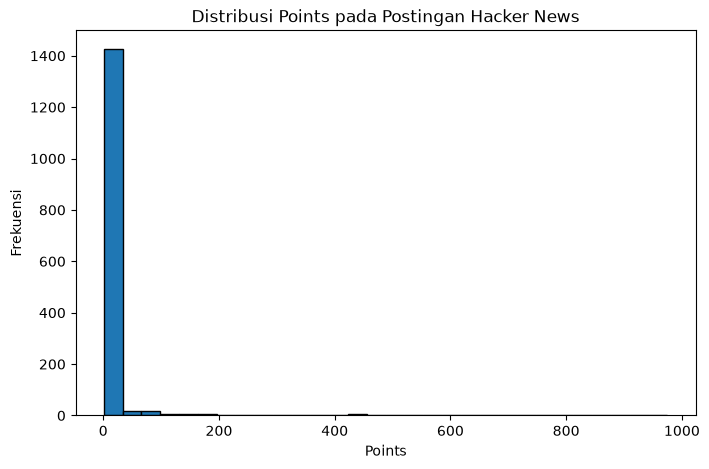

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(df["points"], bins=30, edgecolor="black")

plt.title("Distribusi Points pada Postingan Hacker News")
plt.xlabel("Points")
plt.ylabel("Frekuensi")

plt.show()

**Interpretasi:** Distribusi points didominasi oleh postingan dengan jumlah points yang rendah. Sebagian besar data terkumpul di sisi kiri grafik, sedangkan hanya sedikit postingan yang memiliki points sangat tinggi. Pola ini sesuai dengan median sebesar 2 points dan adanya 167 data yang terdeteksi sebagai outlier berdasarkan metode IQR.

#### Distribusi Comments

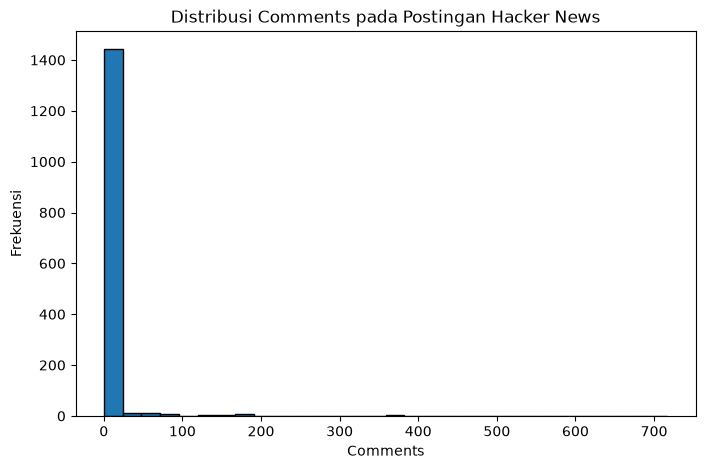

In [31]:
plt.figure(figsize=(8, 5))
plt.hist(df["comments"], bins=30, edgecolor="black")

plt.title("Distribusi Comments pada Postingan Hacker News")
plt.xlabel("Comments")
plt.ylabel("Frekuensi")

plt.show()

**Interpretasi:** Distribusi comments didominasi oleh postingan dengan jumlah komentar yang rendah. Sebagian besar data terkumpul di sisi kiri grafik, dengan median dan modus sebesar 0 komentar. Hanya sedikit postingan yang memiliki jumlah komentar sangat tinggi, sesuai dengan 168 data yang terdeteksi sebagai outlier berdasarkan metode IQR.

#### Distribusi Domain

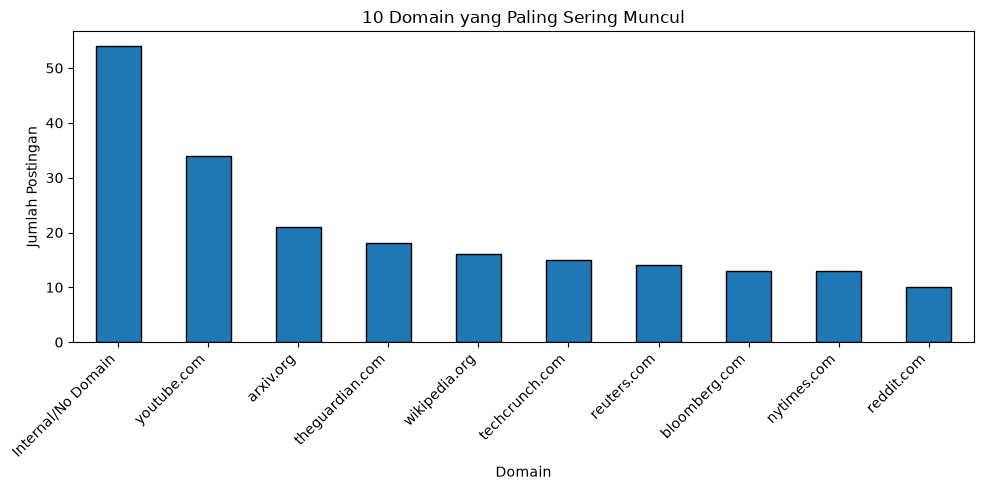

In [32]:
top_domains = df["domain"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_domains.plot(kind="bar", edgecolor="black")

plt.title("10 Domain yang Paling Sering Muncul")
plt.xlabel("Domain")
plt.ylabel("Jumlah Postingan")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**Interpretasi:** Kategori `Internal/No Domain` memiliki jumlah postingan terbanyak, yaitu 54 postingan, karena mencakup data yang tidak memiliki domain eksternal. Di antara domain eksternal, `youtube.com` paling sering muncul dengan 34 postingan, diikuti `arxiv.org` sebanyak 21 postingan. Hasil ini menunjukkan bahwa sumber postingan pada dataset cukup beragam dan tidak didominasi oleh satu domain eksternal.

### 4.2 Visualisasi Bivariat

#### Hubungan Points dan Comments

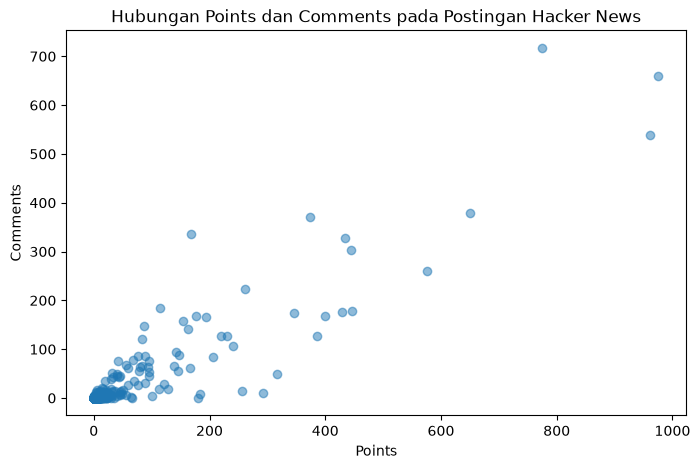

In [33]:
plt.figure(figsize=(8, 5))
plt.scatter(df["points"], df["comments"], alpha=0.5)

plt.title("Hubungan Points dan Comments pada Postingan Hacker News")
plt.xlabel("Points")
plt.ylabel("Comments")

plt.show()

**Interpretasi:** Scatter plot menunjukkan kecenderungan hubungan positif antara `points` dan `comments`. Postingan dengan jumlah points yang lebih tinggi cenderung memiliki jumlah komentar yang lebih banyak. Namun, penyebaran beberapa titik menunjukkan bahwa peningkatan points tidak selalu diikuti jumlah comments yang sama besar.

#### Korelasi Antar Atribut Numerik

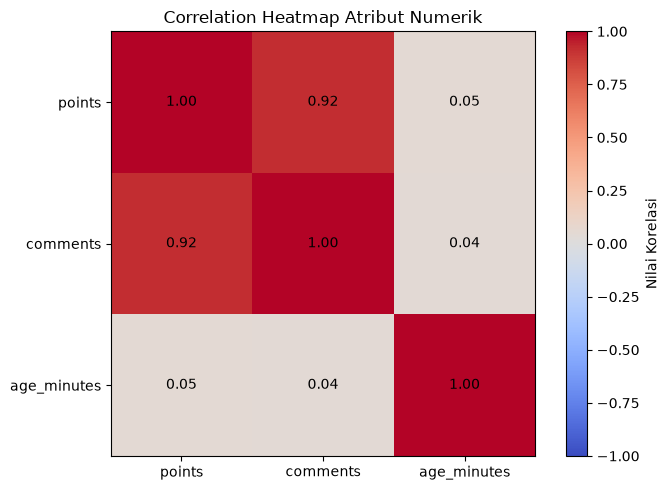

In [34]:
numeric_data = df[["points", "comments", "age_minutes"]]

correlation = numeric_data.corr()

plt.figure(figsize=(7, 5))
plt.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Nilai Korelasi")

plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j, i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap Atribut Numerik")
plt.tight_layout()
plt.show()

**Interpretasi:** Korelasi antara `points` dan `comments` sebesar 0,92 menunjukkan hubungan positif yang sangat kuat. Postingan dengan points lebih tinggi cenderung memiliki jumlah comments yang lebih banyak. Sementara itu, `age_minutes` memiliki korelasi yang sangat lemah dengan `points` sebesar 0,05 dan `comments` sebesar 0,04.

### 4.3 Penyimpanan Dataset Setelah Penanganan

In [35]:
df.to_csv("hackernews_cleaned.csv", index=False)

print("Dataset setelah penanganan berhasil disimpan.")
print("Ukuran dataset:", df.shape)

Dataset setelah penanganan berhasil disimpan.
Ukuran dataset: (1500, 7)
